# Bayesian posterior sampling with the existing ACUOT PPXA solver

This notebook implements the one-dimensional Bayesian inverse problem from Section 6.3 of
[*A machine learning framework for geodesics under the spherical Wasserstein--Fisher--Rao metric and its application for weighted sample generation*](https://arxiv.org/abs/2208.12145).

The default profile, `released_figure8`, is chosen to match the released WFR repository as closely as possible:

- it loads the committed `single_plot_Baysian/bernoulli.npy` endpoint containing **10,000** weighted prior particles;
- it uses eight artificial SHK time cells and source coefficient \(\alpha_{\mathrm{SWFR}}=10\);
- it uses 100,000 newly generated Gaussian particles;
- it uses 250 bins and the released generator's histogram edges for the Figure 8 comparison;
- it uses a 512-cell PPXA spatial grid on \([-6,6]\) and 40,000 PPXA iterations as solver-specific refinement settings.

The alternative `paper_spec` profile regenerates **2,048** importance particles, matching the sample count stated in the paper. Because the released scripts do not record the random seed used for the published observation realization, this second profile is reproducible but is not an exact reconstruction of the published figure.

Only Bayesian data preparation, Eulerian endpoint construction, and weighted-characteristic post-processing are implemented here. The PPXA algorithm itself is called directly through `acuot.computeGeodesic`; no proximal operator, projection, or PPXA iteration is reimplemented.

In [1]:
from pathlib import Path
import math
import os
import sys
import tempfile
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logsumexp
from scipy.stats import norm, wasserstein_distance


def env_flag(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    return value.strip().lower() in {"1", "true", "yes", "on"}


# Make imports work when the notebook is launched from either the repository
# root or the paper/ directory.
_cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (_cwd, _cwd.parent)
        if (candidate / "src" / "acuot").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from the ACUOT repository root or paper/ directory.")
sys.path.insert(0, str(REPO_ROOT / "src"))

from acuot import computeGeodesic
from acuot.grids import speed_and_growth

# ---------------------------------------------------------------------------
# Reproduction profile
# ---------------------------------------------------------------------------
# Override from a shell without editing the notebook, for example:
#   ACUOT_BAYES_PROFILE=paper_spec ACUOT_FAST_RUN=1 jupyter lab
PROFILE = os.environ.get("ACUOT_BAYES_PROFILE", "released_figure8").strip().lower()
if PROFILE not in {"released_figure8", "paper_spec"}:
    raise ValueError("PROFILE must be 'released_figure8' or 'paper_spec'.")

FAST_RUN = env_flag("ACUOT_FAST_RUN", False)
RUN_ONLINE = env_flag("ACUOT_RUN_ONLINE", False)
ALLOW_RELEASED_DATA_DOWNLOAD = env_flag("ACUOT_ALLOW_WFR_DOWNLOAD", True)

# Set WFR_ROOT to a local checkout of https://github.com/sharkjingyang/WFR.
# When it is absent, released artifacts are cached under paper/input/ after a
# pinned download from GitHub.
WFR_ROOT = os.environ.get("WFR_ROOT")
WFR_ROOT = Path(WFR_ROOT).expanduser().resolve() if WFR_ROOT else None
WFR_COMMIT = "b17ef6a9de04f560574145cddf304fd256ca09b3"
WFR_RAW_BASE = f"https://raw.githubusercontent.com/sharkjingyang/WFR/{WFR_COMMIT}"
WFR_CACHE = REPO_ROOT / "paper" / "input" / "wfr-experiment-6.3"

# ---------------------------------------------------------------------------
# Bernoulli inverse problem
# ---------------------------------------------------------------------------
SEED = 58  # Used only for reproducible paper_spec data and new PPXA particles.
N_OBSERVATIONS = 50
OBSERVATION_DT = 1.0
OBSERVATION_NOISE = 0.4
TRUE_INITIAL_STATE = 0.2
PRIOR_MEAN = 0.5
PRIOR_STD = 1.0

# ---------------------------------------------------------------------------
# PPXA and generation settings
# ---------------------------------------------------------------------------
DOMAIN = (-6.0, 6.0)
PLOT_RANGE = (-1.0, 3.0)
PLOT_BINS = 250
ONLINE_PLOT_RANGE = (-1.0, 2.0)
ONLINE_PLOT_BINS = 100

SPACE_CELLS = 64 if FAST_RUN else 512
TRANSPORT_TIME_CELLS = 30
PPXA_ITERATIONS = 300 if FAST_RUN else 5000
ONLINE_PPXA_ITERATIONS = 200 if FAST_RUN else 20_000

# In the deep model, alpha multiplies the squared source rate. The ACUOT
# energy uses delta**2, hence delta=sqrt(alpha) for p=q=2.
ALPHA_SWFR = 10.0
DELTA = math.sqrt(ALPHA_SWFR)
PPXA_RELAXATION = 1.8

N_GENERATED = 2_048 if FAST_RUN else 100_000
PARTICLE_SUBSTEPS = 2 if FAST_RUN else 8
FIELD_MAX_RATIO = 10_000
TRACE_PARTICLES = 32

print(f"Repository root: {REPO_ROOT}")
print(f"Profile: {PROFILE}")
print(
    f"spatial cells={SPACE_CELLS}, SHK time cells={TRANSPORT_TIME_CELLS}, "
    f"PPXA iterations={PPXA_ITERATIONS}, generated particles={N_GENERATED}, "
    f"delta={DELTA:.8g}"
)

Repository root: C:\Users\mao17\Workspace\acuot
Profile: released_figure8
spatial cells=512, SHK time cells=30, PPXA iterations=5000, generated particles=100000, delta=3.1622777


## 1. Bayesian inverse problem and released data

The physical state satisfies

\[
\frac{dv}{d\tau}-v=-v^3,\qquad v(0)=x,
\]

with analytic solution

\[
G(x,\tau)=x\left[x^2+(1-x^2)e^{-2\tau}\right]^{-1/2}.
\]

The static experiment uses \(50\) observations at \(\tau_n=n\), observation-noise standard deviation \(0.4\), true initial state \(x_\star=0.2\), and prior \(\mathcal N(0.5,1)\).

There is a release-versus-paper discrepancy: the paper states 2,048 importance particles, whereas the committed `bernoulli.npy` contains 10,000 particles. The default profile uses the committed array so that the PPXA endpoint is identical to the released experiment's weighted endpoint. `paper_spec` instead generates 2,048 particles from a declared seed.

In [2]:
def forward_map(x, physical_time):
    """Analytic solution G(x, physical_time), with NumPy broadcasting."""
    x = np.asarray(x, dtype=float)
    physical_time = np.asarray(physical_time, dtype=float)
    radicand = x**2 + (1.0 - x**2) * np.exp(-2.0 * physical_time)
    if np.any(radicand <= 0.0):
        raise FloatingPointError("The Bernoulli forward-map radicand became nonpositive.")
    return x / np.sqrt(radicand)


def log_likelihood(x, observation_times, observations, sigma):
    """Log likelihood up to an additive constant independent of x."""
    x = np.asarray(x, dtype=float)
    prediction = forward_map(x[..., None], observation_times)
    residual = (observations - prediction) / sigma
    return -0.5 * np.sum(residual**2, axis=-1)


def normalize_density(density, dx):
    """Normalize cell-centered values so that sum_j density_j * dx = 1."""
    density = np.maximum(np.asarray(density, dtype=float), 0.0)
    mass = float(np.sum(density) * dx)
    if not np.isfinite(mass) or mass <= 0.0:
        raise ValueError("The density has nonpositive or nonfinite mass.")
    return density / mass


def weighted_histogram_density(samples, weights, edges):
    """Project a weighted empirical measure to a finite-volume density."""
    samples = np.asarray(samples, dtype=float).reshape(-1)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    if samples.shape != weights.shape:
        raise ValueError("samples and weights must have the same flattened shape.")
    if np.any(weights < 0.0) or not np.isfinite(weights).all():
        raise ValueError("weights must be finite and nonnegative.")
    weights = weights / np.sum(weights)

    in_domain = (samples >= edges[0]) & (samples <= edges[-1])
    outside_mass = float(np.sum(weights[~in_domain]))
    cell_mass, _ = np.histogram(
        samples[in_domain],
        bins=edges,
        weights=weights[in_domain],
    )
    dx = float(edges[1] - edges[0])
    return normalize_density(cell_mass / dx, dx), outside_mass


def exact_posterior_density(x_grid, dx, observation_times, observations):
    """Normalized posterior for the reproducible paper_spec observation set."""
    log_posterior = norm.logpdf(x_grid, loc=PRIOR_MEAN, scale=PRIOR_STD)
    log_posterior += log_likelihood(
        x_grid,
        observation_times,
        observations,
        OBSERVATION_NOISE,
    )
    log_normalizer = logsumexp(log_posterior) + math.log(dx)
    return np.exp(log_posterior - log_normalizer)


def standard_normal_finite_volume_density(edges):
    """Exact standard-normal probability mass in each finite-volume cell."""
    dx = float(edges[1] - edges[0])
    cell_mass = norm.cdf(edges[1:]) - norm.cdf(edges[:-1])
    return normalize_density(cell_mass / dx, dx)


def sample_truncated_standard_normal(sample_count, left, right, rng):
    """Sample N(0,1) conditioned to the PPXA computational domain."""
    positions = rng.standard_normal(sample_count)
    outside = (positions < left) | (positions > right)
    while np.any(outside):
        positions[outside] = rng.standard_normal(np.count_nonzero(outside))
        outside = (positions < left) | (positions > right)
    return positions


def grid_wasserstein_1(density_a, density_b, x_grid, dx):
    return float(
        wasserstein_distance(
            x_grid,
            x_grid,
            u_weights=np.asarray(density_a, dtype=float) * dx,
            v_weights=np.asarray(density_b, dtype=float) * dx,
        )
    )


def empirical_wasserstein_1(samples_a, weights_a, samples_b, weights_b):
    return float(
        wasserstein_distance(
            np.asarray(samples_a, dtype=float).reshape(-1),
            np.asarray(samples_b, dtype=float).reshape(-1),
            u_weights=np.asarray(weights_a, dtype=float).reshape(-1),
            v_weights=np.asarray(weights_b, dtype=float).reshape(-1),
        )
    )


def curve_quadrature_measure(curve_x, curve_density):
    """Approximate a nonuniformly sampled density curve by weighted atoms."""
    curve_x = np.asarray(curve_x, dtype=float).reshape(-1)
    curve_density = np.asarray(curve_density, dtype=float).reshape(-1)
    if curve_x.shape != curve_density.shape or len(curve_x) < 2:
        raise ValueError("curve_x and curve_density must have the same length >= 2.")
    if not np.isfinite(curve_x).all() or not np.isfinite(curve_density).all():
        raise ValueError("Reference-curve coordinates and densities must be finite.")

    order = np.argsort(curve_x)
    support = curve_x[order]
    density = np.maximum(curve_density[order], 0.0)
    spacing = np.diff(support)
    if np.any(spacing <= 0.0):
        raise ValueError("Reference-curve coordinates must be distinct.")

    # Trapezoidal/Voronoi widths are essential here because the released
    # curve is evaluated at nonuniform prior-particle locations.
    widths = np.empty_like(support)
    widths[0] = 0.5 * spacing[0]
    widths[-1] = 0.5 * spacing[-1]
    widths[1:-1] = 0.5 * (support[2:] - support[:-2])
    masses = density * widths
    total_mass = float(np.sum(masses))
    if not np.isfinite(total_mass) or total_mass <= 0.0:
        raise ValueError("Reference curve has nonpositive or nonfinite mass.")
    return support, masses / total_mass


def load_wfr_artifact(relative_path, *, optional=False):
    """Load a pinned WFR artifact from a local checkout, cache, or GitHub."""
    relative_path = Path(relative_path)
    candidates = []
    if WFR_ROOT is not None:
        candidates.append(WFR_ROOT / relative_path)
    candidates.append(WFR_CACHE / relative_path)

    for candidate in candidates:
        if candidate.is_file():
            return np.load(candidate, allow_pickle=False), candidate

    if not ALLOW_RELEASED_DATA_DOWNLOAD:
        message = (
            f"Missing WFR artifact {relative_path}. Set WFR_ROOT to a local WFR "
            "checkout or enable ACUOT_ALLOW_WFR_DOWNLOAD."
        )
        if optional:
            warnings.warn(message)
            return None, None
        raise FileNotFoundError(message)

    destination = WFR_CACHE / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    url = f"{WFR_RAW_BASE}/{relative_path.as_posix()}"
    temporary_path = None
    try:
        with tempfile.NamedTemporaryFile(
            dir=destination.parent,
            prefix=destination.name + ".",
            suffix=".tmp",
            delete=False,
        ) as temporary_file:
            temporary_path = Path(temporary_file.name)
        urllib.request.urlretrieve(url, temporary_path)
        temporary_path.replace(destination)
        return np.load(destination, allow_pickle=False), destination
    except Exception as error:
        if temporary_path is not None:
            temporary_path.unlink(missing_ok=True)
        message = (
            f"Could not load WFR artifact {relative_path} from {url}. "
            "Set WFR_ROOT to a local checkout of sharkjingyang/WFR. "
            f"Original error: {error}"
        )
        if optional:
            warnings.warn(message)
            return None, None
        raise RuntimeError(message) from error

In [3]:
released_generator_positions = None
released_generator_weights = None
released_generator_paths = None
observations = None
observation_times = OBSERVATION_DT * np.arange(1, N_OBSERVATIONS + 1, dtype=float)

if PROFILE == "released_figure8":
    released_endpoint, released_endpoint_path = load_wfr_artifact(
        "single_plot_Baysian/bernoulli.npy"
    )
    if released_endpoint.shape[0] != 2:
        raise ValueError(
            "Expected released bernoulli.npy to have first dimension 2, "
            f"but found shape {released_endpoint.shape}."
        )

    prior_particles = np.asarray(released_endpoint[0], dtype=float).reshape(-1)
    raw_importance_weights = np.asarray(released_endpoint[1], dtype=float).reshape(-1)
    if len(prior_particles) != 10_000:
        warnings.warn(
            f"The pinned released endpoint contains {len(prior_particles)} particles, "
            "not the expected 10,000."
        )
    importance_weights = raw_importance_weights / np.sum(raw_importance_weights)

    # This is the red reference curve constructed by the released plotting code:
    # normalized likelihood factor times the N(0.5,1) prior density.
    released_curve_order = np.argsort(prior_particles)
    released_curve_x = prior_particles[released_curve_order]
    released_curve_density = (
        raw_importance_weights[released_curve_order]
        * norm.pdf(released_curve_x, loc=PRIOR_MEAN, scale=PRIOR_STD)
    )

    released_positions_array, released_positions_path = load_wfr_artifact(
        "single_plot_Baysian/z_inverse_1d.npy",
        optional=True,
    )
    released_weights_array, released_weights_path = load_wfr_artifact(
        "single_plot_Baysian/w_inverse_1d.npy",
        optional=True,
    )
    if released_positions_array is not None and released_weights_array is not None:
        released_generator_positions = np.asarray(
            released_positions_array, dtype=float
        ).reshape(-1)
        released_generator_weights = np.asarray(
            released_weights_array, dtype=float
        ).reshape(-1)
        if released_generator_positions.shape != released_generator_weights.shape:
            warnings.warn("Released generator positions and weights have incompatible shapes.")
            released_generator_positions = None
            released_generator_weights = None
        else:
            released_generator_weights = (
                released_generator_weights / np.sum(released_generator_weights)
            )
            released_generator_paths = (
                released_positions_path,
                released_weights_path,
            )

    print(f"Loaded released endpoint from: {released_endpoint_path}")
else:
    rng = np.random.default_rng(SEED)
    observations = forward_map(TRUE_INITIAL_STATE, observation_times)
    observations += OBSERVATION_NOISE * rng.standard_normal(N_OBSERVATIONS)

    prior_particles = rng.normal(PRIOR_MEAN, PRIOR_STD, size=2_048)
    log_importance_weights = log_likelihood(
        prior_particles,
        observation_times,
        observations,
        OBSERVATION_NOISE,
    )
    importance_weights = np.exp(
        log_importance_weights - logsumexp(log_importance_weights)
    )
    raw_importance_weights = importance_weights * len(importance_weights)

    released_curve_order = np.argsort(prior_particles)
    released_curve_x = prior_particles[released_curve_order]
    released_curve_density = (
        raw_importance_weights[released_curve_order]
        * norm.pdf(released_curve_x, loc=PRIOR_MEAN, scale=PRIOR_STD)
    )

N_IMPORTANCE = len(prior_particles)
importance_ess = 1.0 / np.sum(importance_weights**2)

if released_generator_positions is not None:
    # The original plot used bins=250 without an explicit range. Reuse the exact
    # edges induced by the released generated positions for a fair overlay.
    figure8_bin_edges = np.histogram_bin_edges(
        released_generator_positions,
        bins=PLOT_BINS,
    )
else:
    figure8_bin_edges = np.linspace(PLOT_RANGE[0], PLOT_RANGE[1], PLOT_BINS + 1)

print(f"Importance particles: {N_IMPORTANCE}")
print(f"Importance-sampling ESS: {importance_ess:.1f} / {N_IMPORTANCE}")
print(f"Largest normalized importance weight: {importance_weights.max():.4e}")
if released_generator_positions is not None:
    print(
        "Released generated particles: "
        f"{len(released_generator_positions)} from {released_generator_paths[0]}"
    )

Loaded released endpoint from: C:\Users\mao17\Workspace\acuot\paper\input\wfr-experiment-6.3\single_plot_Baysian\bernoulli.npy
Importance particles: 10000
Importance-sampling ESS: 5900.6 / 10000
Largest normalized importance weight: 2.8105e-04
Released generated particles: 100000 from C:\Users\mao17\Workspace\acuot\paper\input\wfr-experiment-6.3\single_plot_Baysian\z_inverse_1d.npy


In [4]:
left, right = DOMAIN
edges = np.linspace(left, right, SPACE_CELLS + 1)
x_grid = 0.5 * (edges[:-1] + edges[1:])
dx = float(edges[1] - edges[0])
domain_length = right - left

# Solve directly from the standard Gaussian reference to the posterior. This is
# the reverse orientation of the released training problem, but it is the same
# reversible SHK geodesic and gives the generation direction directly.
rho_0 = standard_normal_finite_volume_density(edges)
rho_1, discarded_posterior_mass = weighted_histogram_density(
    prior_particles,
    importance_weights,
    edges,
)

if PROFILE == "paper_spec":
    rho_exact = exact_posterior_density(
        x_grid,
        dx,
        observation_times,
        observations,
    )
else:
    rho_exact = None

print(f"Spatial cell width dx: {dx:.8f}")
print(f"Reference mass on grid: {np.sum(rho_0) * dx:.12f}")
print(f"Posterior endpoint mass on grid: {np.sum(rho_1) * dx:.12f}")
print(f"Weighted posterior mass outside DOMAIN: {discarded_posterior_mass:.3e}")
if rho_exact is not None:
    print(
        "Input empirical-to-exact W1: "
        f"{grid_wasserstein_1(rho_1, rho_exact, x_grid, dx):.5e}"
    )

Spatial cell width dx: 0.02343750
Reference mass on grid: 1.000000000000
Posterior endpoint mass on grid: 1.000000000000
Weighted posterior mass outside DOMAIN: 0.000e+00


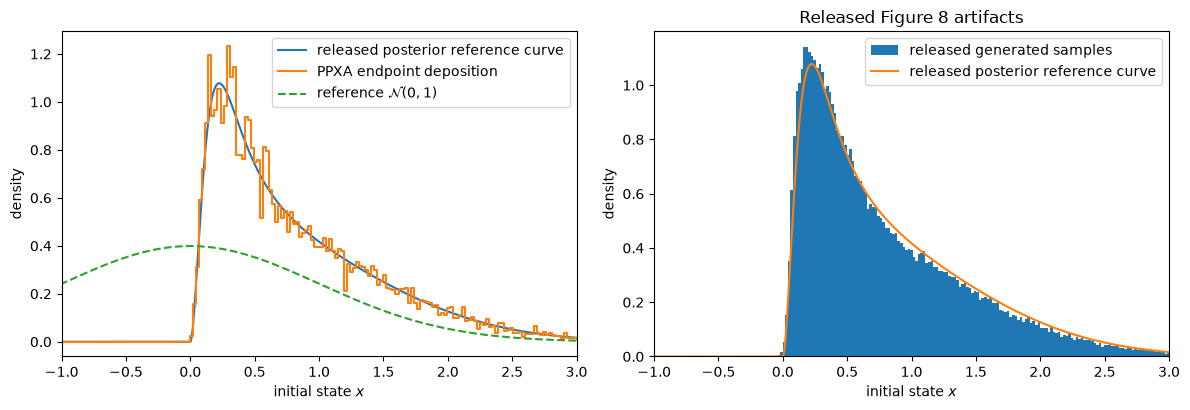

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

if PROFILE == "paper_spec":
    axes[0].plot(
        observation_times,
        forward_map(TRUE_INITIAL_STATE, observation_times),
        label="analytic solution",
    )
    axes[0].scatter(observation_times, observations, s=12, label="observations")
    axes[0].set_xlabel(r"physical time $\tau$")
    axes[0].set_ylabel(r"$v(\tau)$")
    axes[0].legend()

    axes[1].plot(x_grid, rho_exact, label="exact posterior")
    axes[1].step(x_grid, rho_1, where="mid", label="weighted-particle endpoint")
    axes[1].plot(x_grid, rho_0, linestyle="--", label=r"reference $\mathcal{N}(0,1)$")
else:
    axes[0].plot(
        released_curve_x,
        released_curve_density,
        label="released posterior reference curve",
    )
    axes[0].step(x_grid, rho_1, where="mid", label="PPXA endpoint deposition")
    axes[0].plot(x_grid, rho_0, linestyle="--", label=r"reference $\mathcal{N}(0,1)$")
    axes[0].set_xlim(*PLOT_RANGE)
    axes[0].set_xlabel(r"initial state $x$")
    axes[0].set_ylabel("density")
    axes[0].legend()

    if released_generator_positions is not None:
        axes[1].hist(
            released_generator_positions,
            bins=figure8_bin_edges,
            weights=released_generator_weights,
            density=True,
            label="released generated samples",
        )
        axes[1].plot(
            released_curve_x,
            released_curve_density,
            label="released posterior reference curve",
        )
        axes[1].set_title("Released Figure 8 artifacts")
    else:
        axes[1].text(
            0.5,
            0.5,
            "Released generator artifacts were not available.",
            ha="center",
            va="center",
            transform=axes[1].transAxes,
        )

axes[1].set_xlim(*PLOT_RANGE)
axes[1].set_xlabel(r"initial state $x$")
axes[1].set_ylabel("density")
axes[1].legend()

fig.tight_layout()
plt.show()

## 2. Direct call to the repository PPXA solver

The mass-one constraint is

\[
\int_\Omega \rho_s(x)\,dx=1\qquad (0\le s\le 1).
\]

For \(p=q=2\), the ACUOT source term is \(\delta^2\zeta^2/(2\rho)\). Hence the released source coefficient `alphaa=10` corresponds to

\[
\delta=\sqrt{10}.
\]

The original neural solver used eight RK4 time steps. The PPXA notebook therefore also uses eight artificial time cells. The 512 spatial cells and 40,000 PPXA iterations are not neural hyperparameters; they are refinement choices for the Eulerian PPXA discretization.

In [ ]:
# Same constraint layout used in 001-total-mass-constraint.ipynb:
# [H_rho, H_omega, H_zeta] for one one-dimensional constraint block.
H = [[
    np.ones((TRANSPORT_TIME_CELLS, SPACE_CELLS)),
    np.zeros((TRANSPORT_TIME_CELLS, SPACE_CELLS)),
    np.zeros((TRANSPORT_TIME_CELLS, SPACE_CELLS)),
]]
GL = [np.ones(TRANSPORT_TIME_CELLS)]
GU = [np.ones(TRANSPORT_TIME_CELLS)]

geodesic, history = computeGeodesic(
    rho_0.copy(),
    rho_1.copy(),
    TRANSPORT_TIME_CELLS,
    (1.0, domain_length),
    H=H,
    GL=GL,
    GU=GU,
    p=2.0,
    q=2.0,
    delta=DELTA,
    niter=PPXA_ITERATIONS,
    periodic=False,
    alpha=PPXA_RELAXATION,
    verbose=True,
)

Computing a geodesic for optimal transport with source and constraint... (including inequality constraints)
Progress: 0%

Final continuity residual: 2.068363e-07
Final interpolation residual: 0.000000e+00
Maximum mass-one violation: 2.392196e-05
Initial endpoint L1 error: 3.041169e-17
Terminal endpoint L1 error: 1.882446e-17


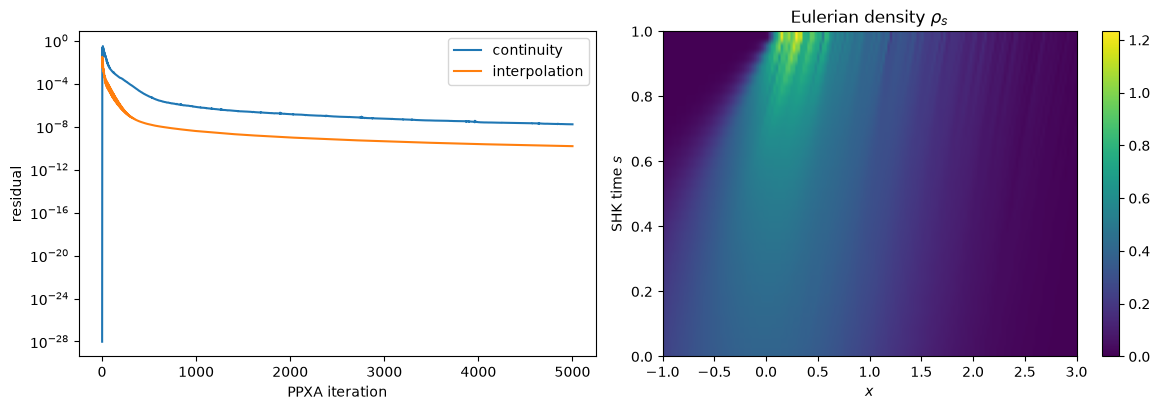

In [ ]:
energy_history, continuity_history, interpolation_history, _, _ = history
rho_nodes = np.asarray(geodesic.U.D[0], dtype=float)
rho_centered = np.asarray(geodesic.V.D[0], dtype=float)
mass_path = np.sum(rho_centered, axis=1) * dx

print(f"Final continuity residual: {geodesic.dist_from_CE():.6e}")
print(f"Final interpolation residual: {geodesic.dist_from_interp():.6e}")
print(f"Maximum mass-one violation: {np.max(np.abs(mass_path - 1.0)):.6e}")
print(f"Initial endpoint L1 error: {np.sum(np.abs(rho_nodes[0] - rho_0)) * dx:.6e}")
print(f"Terminal endpoint L1 error: {np.sum(np.abs(rho_nodes[-1] - rho_1)) * dx:.6e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

iterations = np.arange(1, len(continuity_history) + 1)
tiny = np.finfo(float).tiny
axes[0].semilogy(iterations, np.maximum(continuity_history, tiny), label="continuity")
axes[0].semilogy(iterations, np.maximum(interpolation_history, tiny), label="interpolation")
axes[0].set_xlabel("PPXA iteration")
axes[0].set_ylabel("residual")
axes[0].legend()

image = axes[1].imshow(
    rho_nodes,
    aspect="auto",
    origin="lower",
    extent=(left, right, 0.0, 1.0),
)
axes[1].set_xlim(*PLOT_RANGE)
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"SHK time $s$")
axes[1].set_title(r"Eulerian density $\rho_s$")
fig.colorbar(image, ax=axes[1])

fig.tight_layout()
plt.show()

## 3. Generate new weighted posterior particles

The repository helper `speed_and_growth` extracts

\[
v_s=\frac{\omega_s}{\rho_s},\qquad r_s=\frac{\zeta_s}{\rho_s}
\]

from the PPXA solution. The Bayesian post-processing step integrates

\[
\dot X_i(s)=v_s(X_i(s)),\qquad
\frac{d}{ds}\log W_i(s)=r_s(X_i(s))
\]

from equally weighted samples drawn directly from the standard Gaussian, truncated only at the remote PPXA boundaries \([-6,6]\). The full released-profile run uses 100,000 particles and eight midpoint substeps in each PPXA time cell.

In [ ]:
def generate_weighted_samples_from_geodesic(
    geodesic,
    x_grid,
    edges,
    *,
    particle_count,
    substeps_per_time_cell,
    rng,
    trace_count=0,
):
    """Weighted-characteristic sampling from an ACUOT geodesic."""
    velocity_components, growth = speed_and_growth(
        geodesic.V,
        max_ratio=FIELD_MAX_RATIO,
    )
    velocity = np.asarray(velocity_components[0], dtype=float)
    growth = np.asarray(growth, dtype=float)
    rho = np.asarray(geodesic.V.D[0], dtype=float)

    time_cell_count = velocity.shape[0]
    left, right = float(edges[0]), float(edges[-1])
    positions = sample_truncated_standard_normal(
        particle_count,
        left,
        right,
        rng,
    )
    log_weights = np.full(particle_count, -math.log(particle_count), dtype=float)

    trace_count = min(trace_count, particle_count)
    trace_positions = np.empty((time_cell_count + 1, trace_count))
    trace_weights = np.empty((time_cell_count + 1, trace_count))
    if trace_count:
        trace_positions[0] = positions[:trace_count]
        trace_weights[0] = 1.0

    ds = 1.0 / (time_cell_count * substeps_per_time_cell)
    epsilon = 10.0 * np.finfo(float).eps * max(1.0, right - left)
    attempted_exits = 0

    for time_index in range(time_cell_count):
        for _ in range(substeps_per_time_cell):
            v_start = np.interp(
                positions,
                x_grid,
                velocity[time_index],
                left=0.0,
                right=0.0,
            )
            midpoint = positions + 0.5 * ds * v_start
            v_midpoint = np.interp(
                midpoint,
                x_grid,
                velocity[time_index],
                left=0.0,
                right=0.0,
            )
            r_midpoint = np.interp(
                midpoint,
                x_grid,
                growth[time_index],
                left=0.0,
                right=0.0,
            )

            proposed = positions + ds * v_midpoint
            attempted_exits += int(
                np.count_nonzero((proposed < left) | (proposed > right))
            )
            positions = np.clip(proposed, left + epsilon, right - epsilon)
            log_weights += ds * r_midpoint
            # Recenter for numerical stability; normalized weights are unchanged.
            log_weights -= np.max(log_weights)

        if trace_count:
            normalized = np.exp(log_weights - logsumexp(log_weights))
            trace_positions[time_index + 1] = positions[:trace_count]
            trace_weights[time_index + 1] = particle_count * normalized[:trace_count]

    weights = np.exp(log_weights - logsumexp(log_weights))
    threshold = np.max(rho) / FIELD_MAX_RATIO
    suppressed_mass = np.max(
        np.sum(np.where(rho <= threshold, rho, 0.0), axis=1) * dx
    )

    return {
        "positions": positions,
        "weights": weights,
        "velocity": velocity,
        "growth": growth,
        "trace_positions": trace_positions,
        "trace_weights": trace_weights,
        "attempted_boundary_exit_fraction": attempted_exits
        / (particle_count * time_cell_count * substeps_per_time_cell),
        "maximum_suppressed_density_mass": float(suppressed_mass),
    }

Generated ESS: 99675.5 / 100000
Largest generated weight: 1.1848e-05
PPXA generated-to-input empirical W1: 2.74125e-03
PPXA generated-to-released-reference-curve W1: 8.58316e-03
Released generated-to-input empirical W1: 3.99247e-02
Released generated-to-released-reference-curve W1: 4.63986e-02
Generated mass outside grid before projection: 0.000e+00
Attempted boundary-exit fraction: 0.000e+00
Maximum density mass suppressed by speed_and_growth: 9.800e-05


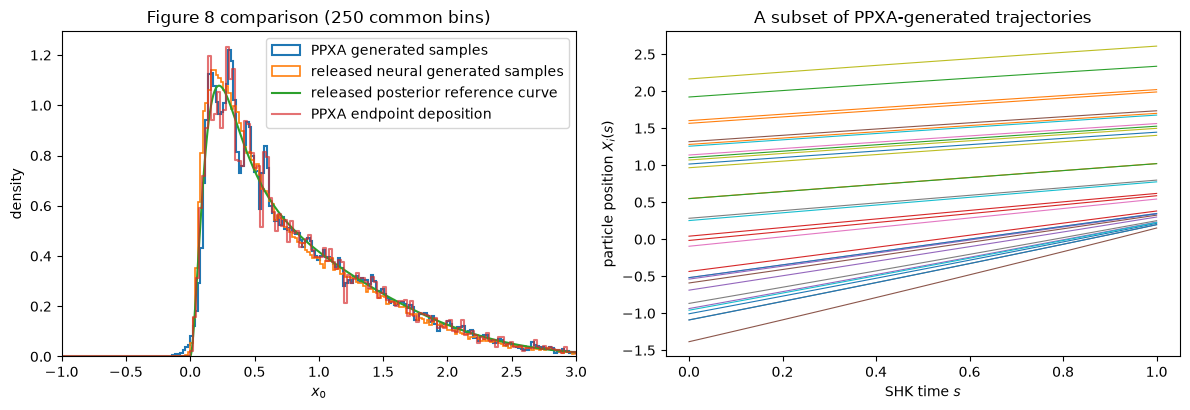

In [13]:
generation_rng = np.random.default_rng(SEED + 1)
generated = generate_weighted_samples_from_geodesic(
    geodesic,
    x_grid,
    edges,
    particle_count=N_GENERATED,
    substeps_per_time_cell=PARTICLE_SUBSTEPS,
    rng=generation_rng,
    trace_count=TRACE_PARTICLES,
)

generated_density, generated_outside_mass = weighted_histogram_density(
    generated["positions"],
    generated["weights"],
    edges,
)
generated_ess = 1.0 / np.sum(generated["weights"] ** 2)
generated_to_input_w1 = empirical_wasserstein_1(
    generated["positions"],
    generated["weights"],
    prior_particles,
    importance_weights,
)

print(f"Generated ESS: {generated_ess:.1f} / {N_GENERATED}")
print(f"Largest generated weight: {generated['weights'].max():.4e}")
print(f"PPXA generated-to-input empirical W1: {generated_to_input_w1:.5e}")
if PROFILE == "released_figure8":
    reference_curve_support, reference_curve_weights = curve_quadrature_measure(
        released_curve_x,
        released_curve_density,
    )
    generated_to_reference_curve_w1 = empirical_wasserstein_1(
        generated["positions"],
        generated["weights"],
        reference_curve_support,
        reference_curve_weights,
    )
    print(
        "PPXA generated-to-released-reference-curve W1: "
        f"{generated_to_reference_curve_w1:.5e}"
    )
if rho_exact is not None:
    print(
        "PPXA generated-to-exact grid W1: "
        f"{grid_wasserstein_1(generated_density, rho_exact, x_grid, dx):.5e}"
    )
if released_generator_positions is not None:
    released_to_input_w1 = empirical_wasserstein_1(
        released_generator_positions,
        released_generator_weights,
        prior_particles,
        importance_weights,
    )
    print(f"Released generated-to-input empirical W1: {released_to_input_w1:.5e}")
    if PROFILE == "released_figure8":
        released_to_reference_curve_w1 = empirical_wasserstein_1(
            released_generator_positions,
            released_generator_weights,
            reference_curve_support,
            reference_curve_weights,
        )
        print(
            "Released generated-to-released-reference-curve W1: "
            f"{released_to_reference_curve_w1:.5e}"
        )
print(f"Generated mass outside grid before projection: {generated_outside_mass:.3e}")
print(f"Attempted boundary-exit fraction: {generated['attempted_boundary_exit_fraction']:.3e}")
print(
    "Maximum density mass suppressed by speed_and_growth: "
    f"{generated['maximum_suppressed_density_mass']:.3e}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(
    generated["positions"],
    bins=figure8_bin_edges,
    weights=generated["weights"],
    density=True,
    histtype="step",
    linewidth=1.5,
    label="PPXA generated samples",
)
if released_generator_positions is not None:
    axes[0].hist(
        released_generator_positions,
        bins=figure8_bin_edges,
        weights=released_generator_weights,
        density=True,
        histtype="step",
        linewidth=1.2,
        label="released neural generated samples",
    )
if rho_exact is not None:
    axes[0].plot(x_grid, rho_exact, label="exact posterior")
else:
    axes[0].plot(
        released_curve_x,
        released_curve_density,
        label="released posterior reference curve",
    )
axes[0].step(x_grid, rho_1, where="mid", alpha=0.65, label="PPXA endpoint deposition")
axes[0].set_xlim(*PLOT_RANGE)
axes[0].set_xlabel(r"$x_0$")
axes[0].set_ylabel("density")
axes[0].set_title(f"Figure 8 comparison ({PLOT_BINS} common bins)")
axes[0].legend()

trace_positions = generated["trace_positions"]
transport_times = np.linspace(0.0, 1.0, trace_positions.shape[0])
for particle_index in range(trace_positions.shape[1]):
    axes[1].plot(transport_times, trace_positions[:, particle_index], linewidth=0.8)
axes[1].set_xlabel(r"SHK time $s$")
axes[1].set_ylabel(r"particle position $X_i(s)$")
axes[1].set_title("A subset of PPXA-generated trajectories")

fig.tight_layout()
plt.show()

## 4. Optional online experiment (Figure 9 analogue)

Set `ACUOT_RUN_ONLINE=1` before launching Jupyter, or set `RUN_ONLINE=True` in the configuration cell, to execute the sequential experiment. It uses observation spacing \(0.1\), blocks of five observations, 100 plotting bins, and the released `posterior_data/observe.npy` realization when the default profile is active.

At each update, the current generated particles are reweighted by the new likelihood block, deposited on the PPXA grid, and used as the next endpoint. The previous ACUOT primal fields are supplied as a manual warm start. The same repository `computeGeodesic` function is used at every update.

In [ ]:
if RUN_ONLINE:
    online_rng = np.random.default_rng(SEED + 10_000)
    online_times = 0.1 * np.arange(1, N_OBSERVATIONS + 1, dtype=float)

    if PROFILE == "released_figure8":
        released_online_observations, released_online_path = load_wfr_artifact(
            "posterior_data/observe.npy"
        )
        released_online_observations = np.asarray(
            released_online_observations, dtype=float
        ).reshape(-1)
        if len(released_online_observations) != N_OBSERVATIONS + 1:
            raise ValueError(
                "Expected released observe.npy to contain times 0 through 5 "
                f"({N_OBSERVATIONS + 1} values), found {len(released_online_observations)}."
            )
        online_observations = released_online_observations[1:]
        print(f"Loaded released online observations from: {released_online_path}")
    else:
        online_observations = forward_map(TRUE_INITIAL_STATE, online_times)
        online_observations += (
            OBSERVATION_NOISE * online_rng.standard_normal(N_OBSERVATIONS)
        )

    online_positions = online_rng.normal(PRIOR_MEAN, PRIOR_STD, size=N_IMPORTANCE)
    online_weights = np.full(N_IMPORTANCE, 1.0 / N_IMPORTANCE)
    previous_geodesic = None
    online_checkpoints = {}
    requested_checkpoints = {5: 0.5, 10: 1.0, 20: 2.0, 50: 5.0}

    for block_end in range(5, N_OBSERVATIONS + 1, 5):
        block_start = block_end - 5
        new_log_weights = np.log(
            np.maximum(online_weights, np.finfo(float).tiny)
        )
        new_log_weights += log_likelihood(
            online_positions,
            online_times[block_start:block_end],
            online_observations[block_start:block_end],
            OBSERVATION_NOISE,
        )
        online_weights = np.exp(new_log_weights - logsumexp(new_log_weights))
        online_target, online_outside_mass = weighted_histogram_density(
            online_positions,
            online_weights,
            edges,
        )

        warm_start = {}
        if previous_geodesic is not None:
            warm_start = {
                "init": "manual",
                "U": previous_geodesic.U,
                "V": previous_geodesic.V,
            }

        current_geodesic, _ = computeGeodesic(
            rho_0.copy(),
            online_target.copy(),
            TRANSPORT_TIME_CELLS,
            (1.0, domain_length),
            H=H,
            GL=GL,
            GU=GU,
            p=2.0,
            q=2.0,
            delta=DELTA,
            niter=ONLINE_PPXA_ITERATIONS,
            periodic=False,
            alpha=PPXA_RELAXATION,
            verbose=False,
            **warm_start,
        )

        online_generated = generate_weighted_samples_from_geodesic(
            current_geodesic,
            x_grid,
            edges,
            particle_count=N_IMPORTANCE,
            substeps_per_time_cell=PARTICLE_SUBSTEPS,
            rng=online_rng,
        )
        online_positions = online_generated["positions"]
        online_weights = online_generated["weights"]
        previous_geodesic = current_geodesic

        if block_end in requested_checkpoints:
            exact_at_checkpoint = exact_posterior_density(
                x_grid,
                dx,
                online_times[:block_end],
                online_observations[:block_end],
            )
            online_checkpoints[requested_checkpoints[block_end]] = {
                "exact": exact_at_checkpoint,
                "positions": online_positions.copy(),
                "weights": online_weights.copy(),
                "ess": 1.0 / np.sum(online_weights**2),
                "outside_mass": online_outside_mass,
            }

        print(
            f"Assimilated {block_end:2d}/{N_OBSERVATIONS} observations; "
            f"ESS={1.0 / np.sum(online_weights**2):7.1f}"
        )
else:
    online_checkpoints = {}
    print("Online experiment skipped. Set ACUOT_RUN_ONLINE=1 to execute it.")

Online experiment skipped. Set ACUOT_RUN_ONLINE=1 to execute it.


In [ ]:
if RUN_ONLINE:
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
    for axis, checkpoint in zip(axes, (0.5, 1.0, 2.0, 5.0)):
        result = online_checkpoints[checkpoint]
        axis.hist(
            result["positions"],
            bins=ONLINE_PLOT_BINS,
            range=ONLINE_PLOT_RANGE,
            weights=result["weights"],
            density=True,
            label="PPXA generated samples",
        )
        axis.plot(x_grid, result["exact"], label="exact posterior")
        axis.set_xlim(*ONLINE_PLOT_RANGE)
        axis.set_title(f"physical time = {checkpoint:g}")
        axis.set_xlabel(r"$x_0$")
        axis.text(
            0.03,
            0.95,
            f"ESS={result['ess']:.0f}",
            transform=axis.transAxes,
            va="top",
        )
    axes[0].set_ylabel("density")
    axes[0].legend()
    fig.tight_layout()
    plt.show()

## Reading the result

The terminal Eulerian density is imposed as a hard PPXA endpoint, so agreement of `geodesic.U.D[0][-1]` with `rho_1` is mainly a solver-residual check. The nontrivial sampling test is the weighted empirical measure reconstructed from **new Gaussian particles** after integrating the returned velocity and growth fields.

For the default released profile, the most direct quantitative comparisons are

\[
W_1(\widehat\pi_{\mathrm{PPXA}},\pi_{\mathrm{released\ input}})
\quad\text{and}\quad
W_1(\widehat\pi_{\mathrm{neural}},\pi_{\mathrm{released\ input}}),
\]

computed without histogram binning. The shared 250-bin plot is included to match the released Figure 8 presentation, while the Wasserstein comparisons avoid dependence on the visualization bins.